Installing Dependencies

In [ ]:
!pip3 install tensorflow-gpu==1.15
!pip3 install Keras==2.2.5
!pip3 install numpy==1.19.5
!pip3 install h5py==2.10.0 
!pip3 install scipy==1.4.1
!pip3 install pycocotools==2.0.1

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 411.5 MB 7.7 kB/s 
     |████████████████████████████████| 50 kB 8.1 MB/s 
     |████████████████████████████████| 3.8 MB 45.3 MB/s 
     |████████████████████████████████| 503 kB 62.0 MB/s 
  Created wheel for gast: filename=gast-0.2.2-py3-none-any.whl size=7554 sha256=2f60bccb07ece98d754656496edfabc9f3a1d981e03697f189cadefd5119d269
  Stored in directory: /root/.cache/pip/wheels/21/7f/02/420f32a803f7d0967b48dd823da3f558c5166991bfd204eef3
Successfully built gast
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.8.0
    Uninstalling tensorflow-estimator-2.8.0:
      Successfully uninstalled tensorflow-estimator-2.8.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.8.0
    Uninstalling tensorboard-2.8.0:
      Successfully uninstalled tensorboard-2.8.0
  Attempting u

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 2.9 MB 4.3 MB/s 
  Attempting uninstall: h5py
    Found existing installation: h5py 3.1.0
    Uninstalling h5py-3.1.0:
      Successfully uninstalled h5py-3.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.8.2+zzzcolab20220719082949 requires keras<2.9,>=2.8.0rc0, but you have keras 2.2.5 which is incompatible.
tensorflow 2.8.2+zzzcolab20220719082949 requires numpy>=1.20, but you have numpy 1.19.5 which is incompatible.
tensorflow 2.8.2+zzzcolab20220719082949 requires tensorboard<2.9,>=2.8, but you have tensorboard 1.15.0 which is incompatible.
tensorflow 2.8.2+zzzcolab20220719082949 requires tensorflow-estimator<2.9,>=2.8, but you have tensorflow-estimator 1.15.1 which is incompatible.
Looking in indexes: htt

Please Restart Runtime 

Mounting Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/EfficientDet

/content/drive/MyDrive/EfficientDet


In [ ]:
!python3 setup.py build_ext --inplace

Compiling utils/compute_overlap.pyx because it changed.
[1/1] Cythonizing utils/compute_overlap.pyx
/usr/local/lib/python3.7/dist-packages/Cython/Compiler/Main.py:369: FutureWarning: Cython directive 'language_level' not set, using 2 for now (Py2). This will change in a later release! File: /content/drive/MyDrive/EfficientDet/utils/compute_overlap.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
running build_ext
building 'utils.compute_overlap' extension
creating build
creating build/temp.linux-x86_64-3.7
creating build/temp.linux-x86_64-3.7/utils
x86_64-linux-gnu-gcc -pthread -Wno-unused-result -Wsign-compare -DNDEBUG -g -fwrapv -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -g -fstack-protector-strong -Wformat -Werror=format-security -Wdate-time -D_FORTIFY_SOURCE=2 -fPIC -I/usr/local/lib/python3.7/dist-packages/numpy/core/include -I/usr/include/python3.7m -c utils/compute_overlap.c -o build/temp.linux-x86_64-3.7/utils/compute_overlap.o
I

Importing Libraries

In [ ]:
import cv2
import json
from datetime import date
import sys
import numpy as np
import os
import time
import glob
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from utils import preprocess_image, postprocess_boxes
from utils.draw_boxes import draw_boxes
from tensorflow.keras import layers
from tensorflow.keras import initializers
from tensorflow.keras import models
from tfkeras import EfficientNetB0, EfficientNetB1, EfficientNetB2
from tfkeras import EfficientNetB3, EfficientNetB4, EfficientNetB5, EfficientNetB6
from layers import ClipBoxes, RegressBoxes, FilterDetections, wBiFPNAdd, BatchNormalization
from initializers import PriorProbability
from utils.anchors import anchors_for_shape
from functools import reduce
from tensorflow.keras.optimizers import Adam, SGD
from augmentor.color import VisualEffect
from augmentor.misc import MiscEffect
from losses import smooth_l1, focal, smooth_l1_quad
from efficientnet import BASE_WEIGHTS_PATH, WEIGHTS_HASHES




Defining Variables

In [ ]:
num_classes = 90
score_threshold = 0.3
phi = 1
weighted_bifpn = True
image_sizes = (512, 640, 768, 896, 1024, 1280, 1408)

parent_dir="/content/drive/MyDrive/EfficientDet"
model_path = parent_dir + '/model'
snapshot_path=model_path+'/coco.h5'
ckpt=model_path+'/efficientdet-d1.h5'
dataset_path=parent_dir+'/coco/images'
coco_path=parent_dir+'/coco'
dir_path=dataset_path+'/val2017'

w_bifpns = [64, 88, 112, 160, 224, 288, 384]
d_bifpns = [3, 4, 5, 6, 7, 7, 8]
d_heads = [3, 3, 3, 4, 4, 4, 5]
image_sizes = [512, 640, 768, 896, 1024, 1280, 1408]
backbones = [EfficientNetB0, EfficientNetB1, EfficientNetB2,
             EfficientNetB3, EfficientNetB4, EfficientNetB5, EfficientNetB6]

MOMENTUM = 0.997
EPSILON = 1e-4
batch_size=8
freeze_bn=True
detect_quadrangle=False
detect_text=False
gpu=1
steps=100

Defining Model EfficientDet

In [ ]:
def SeparableConvBlock(num_channels, kernel_size, strides, name, freeze_bn=False):
    f1 = layers.SeparableConv2D(num_channels, kernel_size=kernel_size, strides=strides, padding='same',
                                use_bias=True, name=f'{name}/conv')
    f2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name=f'{name}/bn')
    # f2 = BatchNormalization(freeze=freeze_bn, name=f'{name}/bn')
    return reduce(lambda f, g: lambda *args, **kwargs: g(f(*args, **kwargs)), (f1, f2))


def ConvBlock(num_channels, kernel_size, strides, name, freeze_bn=False):
    f1 = layers.Conv2D(num_channels, kernel_size=kernel_size, strides=strides, padding='same',
                       use_bias=True, name='{}_conv'.format(name))
    f2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name='{}_bn'.format(name))
    # f2 = BatchNormalization(freeze=freeze_bn, name='{}_bn'.format(name))
    f3 = layers.ReLU(name='{}_relu'.format(name))
    return reduce(lambda f, g: lambda *args, **kwargs: g(f(*args, **kwargs)), (f1, f2, f3))


def build_wBiFPN(features, num_channels, id, freeze_bn=False):
    if id == 0:
        _, _, C3, C4, C5 = features
        P3_in = C3
        P4_in = C4
        P5_in = C5
        P6_in = layers.Conv2D(num_channels, kernel_size=1, padding='same', name='resample_p6/conv2d')(C5)
        P6_in = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name='resample_p6/bn')(P6_in)
        # P6_in = BatchNormalization(freeze=freeze_bn, name='resample_p6/bn')(P6_in)
        P6_in = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='resample_p6/maxpool')(P6_in)
        P7_in = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='resample_p7/maxpool')(P6_in)
        P7_U = layers.UpSampling2D()(P7_in)
        P6_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode0/add')([P6_in, P7_U])
        P6_td = layers.Activation(lambda x: tf.nn.swish(x))(P6_td)
        P6_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode0/op_after_combine5')(P6_td)
        P5_in_1 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/conv2d')(P5_in)
        P5_in_1 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/bn')(P5_in_1)
        # P5_in_1 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/bn')(P5_in_1)
        P6_U = layers.UpSampling2D()(P6_td)
        P5_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode1/add')([P5_in_1, P6_U])
        P5_td = layers.Activation(lambda x: tf.nn.swish(x))(P5_td)
        P5_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode1/op_after_combine6')(P5_td)
        P4_in_1 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/conv2d')(P4_in)
        P4_in_1 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/bn')(P4_in_1)
        # P4_in_1 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/bn')(P4_in_1)
        P5_U = layers.UpSampling2D()(P5_td)
        P4_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode2/add')([P4_in_1, P5_U])
        P4_td = layers.Activation(lambda x: tf.nn.swish(x))(P4_td)
        P4_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode2/op_after_combine7')(P4_td)
        P3_in = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                              name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/conv2d')(P3_in)
        P3_in = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                          name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/bn')(P3_in)
        # P3_in = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/bn')(P3_in)
        P4_U = layers.UpSampling2D()(P4_td)
        P3_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode3/add')([P3_in, P4_U])
        P3_out = layers.Activation(lambda x: tf.nn.swish(x))(P3_out)
        P3_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode3/op_after_combine8')(P3_out)
        P4_in_2 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/conv2d')(P4_in)
        P4_in_2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/bn')(P4_in_2)
        # P4_in_2 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/bn')(P4_in_2)
        P3_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P3_out)
        P4_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode4/add')([P4_in_2, P4_td, P3_D])
        P4_out = layers.Activation(lambda x: tf.nn.swish(x))(P4_out)
        P4_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode4/op_after_combine9')(P4_out)

        P5_in_2 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/conv2d')(P5_in)
        P5_in_2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/bn')(P5_in_2)
        # P5_in_2 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/bn')(P5_in_2)
        P4_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P4_out)
        P5_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode5/add')([P5_in_2, P5_td, P4_D])
        P5_out = layers.Activation(lambda x: tf.nn.swish(x))(P5_out)
        P5_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode5/op_after_combine10')(P5_out)

        P5_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P5_out)
        P6_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode6/add')([P6_in, P6_td, P5_D])
        P6_out = layers.Activation(lambda x: tf.nn.swish(x))(P6_out)
        P6_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode6/op_after_combine11')(P6_out)

        P6_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P6_out)
        P7_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode7/add')([P7_in, P6_D])
        P7_out = layers.Activation(lambda x: tf.nn.swish(x))(P7_out)
        P7_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode7/op_after_combine12')(P7_out)

    else:
        P3_in, P4_in, P5_in, P6_in, P7_in = features
        P7_U = layers.UpSampling2D()(P7_in)
        P6_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode0/add')([P6_in, P7_U])
        P6_td = layers.Activation(lambda x: tf.nn.swish(x))(P6_td)
        P6_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode0/op_after_combine5')(P6_td)
        P6_U = layers.UpSampling2D()(P6_td)
        P5_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode1/add')([P5_in, P6_U])
        P5_td = layers.Activation(lambda x: tf.nn.swish(x))(P5_td)
        P5_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode1/op_after_combine6')(P5_td)
        P5_U = layers.UpSampling2D()(P5_td)
        P4_td = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode2/add')([P4_in, P5_U])
        P4_td = layers.Activation(lambda x: tf.nn.swish(x))(P4_td)
        P4_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode2/op_after_combine7')(P4_td)
        P4_U = layers.UpSampling2D()(P4_td)
        P3_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode3/add')([P3_in, P4_U])
        P3_out = layers.Activation(lambda x: tf.nn.swish(x))(P3_out)
        P3_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode3/op_after_combine8')(P3_out)
        P3_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P3_out)
        P4_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode4/add')([P4_in, P4_td, P3_D])
        P4_out = layers.Activation(lambda x: tf.nn.swish(x))(P4_out)
        P4_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode4/op_after_combine9')(P4_out)

        P4_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P4_out)
        P5_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode5/add')([P5_in, P5_td, P4_D])
        P5_out = layers.Activation(lambda x: tf.nn.swish(x))(P5_out)
        P5_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode5/op_after_combine10')(P5_out)

        P5_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P5_out)
        P6_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode6/add')([P6_in, P6_td, P5_D])
        P6_out = layers.Activation(lambda x: tf.nn.swish(x))(P6_out)
        P6_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode6/op_after_combine11')(P6_out)

        P6_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P6_out)
        P7_out = wBiFPNAdd(name=f'fpn_cells/cell_{id}/fnode7/add')([P7_in, P6_D])
        P7_out = layers.Activation(lambda x: tf.nn.swish(x))(P7_out)
        P7_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode7/op_after_combine12')(P7_out)
    return P3_out, P4_td, P5_td, P6_td, P7_out


def build_BiFPN(features, num_channels, id, freeze_bn=False):
    if id == 0:
        _, _, C3, C4, C5 = features
        P3_in = C3
        P4_in = C4
        P5_in = C5
        P6_in = layers.Conv2D(num_channels, kernel_size=1, padding='same', name='resample_p6/conv2d')(C5)
        P6_in = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name='resample_p6/bn')(P6_in)
        # P6_in = BatchNormalization(freeze=freeze_bn, name='resample_p6/bn')(P6_in)
        P6_in = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='resample_p6/maxpool')(P6_in)
        P7_in = layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='resample_p7/maxpool')(P6_in)
        P7_U = layers.UpSampling2D()(P7_in)
        P6_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode0/add')([P6_in, P7_U])
        P6_td = layers.Activation(lambda x: tf.nn.swish(x))(P6_td)
        P6_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode0/op_after_combine5')(P6_td)
        P5_in_1 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/conv2d')(P5_in)
        P5_in_1 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/bn')(P5_in_1)
        # P5_in_1 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode1/resample_0_2_6/bn')(P5_in_1)
        P6_U = layers.UpSampling2D()(P6_td)
        P5_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode1/add')([P5_in_1, P6_U])
        P5_td = layers.Activation(lambda x: tf.nn.swish(x))(P5_td)
        P5_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode1/op_after_combine6')(P5_td)
        P4_in_1 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/conv2d')(P4_in)
        P4_in_1 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/bn')(P4_in_1)
        # P4_in_1 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode2/resample_0_1_7/bn')(P4_in_1)
        P5_U = layers.UpSampling2D()(P5_td)
        P4_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode2/add')([P4_in_1, P5_U])
        P4_td = layers.Activation(lambda x: tf.nn.swish(x))(P4_td)
        P4_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode2/op_after_combine7')(P4_td)
        P3_in = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                              name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/conv2d')(P3_in)
        P3_in = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                          name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/bn')(P3_in)
        # P3_in = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode3/resample_0_0_8/bn')(P3_in)
        P4_U = layers.UpSampling2D()(P4_td)
        P3_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode3/add')([P3_in, P4_U])
        P3_out = layers.Activation(lambda x: tf.nn.swish(x))(P3_out)
        P3_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode3/op_after_combine8')(P3_out)
        P4_in_2 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/conv2d')(P4_in)
        P4_in_2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/bn')(P4_in_2)
        # P4_in_2 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode4/resample_0_1_9/bn')(P4_in_2)
        P3_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P3_out)
        P4_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode4/add')([P4_in_2, P4_td, P3_D])
        P4_out = layers.Activation(lambda x: tf.nn.swish(x))(P4_out)
        P4_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode4/op_after_combine9')(P4_out)

        P5_in_2 = layers.Conv2D(num_channels, kernel_size=1, padding='same',
                                name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/conv2d')(P5_in)
        P5_in_2 = layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON,
                                            name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/bn')(P5_in_2)
        # P5_in_2 = BatchNormalization(freeze=freeze_bn, name=f'fpn_cells/cell_{id}/fnode5/resample_0_2_10/bn')(P5_in_2)
        P4_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P4_out)
        P5_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode5/add')([P5_in_2, P5_td, P4_D])
        P5_out = layers.Activation(lambda x: tf.nn.swish(x))(P5_out)
        P5_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode5/op_after_combine10')(P5_out)

        P5_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P5_out)
        P6_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode6/add')([P6_in, P6_td, P5_D])
        P6_out = layers.Activation(lambda x: tf.nn.swish(x))(P6_out)
        P6_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode6/op_after_combine11')(P6_out)

        P6_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P6_out)
        P7_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode7/add')([P7_in, P6_D])
        P7_out = layers.Activation(lambda x: tf.nn.swish(x))(P7_out)
        P7_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode7/op_after_combine12')(P7_out)

    else:
        P3_in, P4_in, P5_in, P6_in, P7_in = features
        P7_U = layers.UpSampling2D()(P7_in)
        P6_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode0/add')([P6_in, P7_U])
        P6_td = layers.Activation(lambda x: tf.nn.swish(x))(P6_td)
        P6_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode0/op_after_combine5')(P6_td)
        P6_U = layers.UpSampling2D()(P6_td)
        P5_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode1/add')([P5_in, P6_U])
        P5_td = layers.Activation(lambda x: tf.nn.swish(x))(P5_td)
        P5_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode1/op_after_combine6')(P5_td)
        P5_U = layers.UpSampling2D()(P5_td)
        P4_td = layers.Add(name=f'fpn_cells/cell_{id}/fnode2/add')([P4_in, P5_U])
        P4_td = layers.Activation(lambda x: tf.nn.swish(x))(P4_td)
        P4_td = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                   name=f'fpn_cells/cell_{id}/fnode2/op_after_combine7')(P4_td)
        P4_U = layers.UpSampling2D()(P4_td)
        P3_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode3/add')([P3_in, P4_U])
        P3_out = layers.Activation(lambda x: tf.nn.swish(x))(P3_out)
        P3_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode3/op_after_combine8')(P3_out)
        P3_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P3_out)
        P4_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode4/add')([P4_in, P4_td, P3_D])
        P4_out = layers.Activation(lambda x: tf.nn.swish(x))(P4_out)
        P4_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode4/op_after_combine9')(P4_out)

        P4_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P4_out)
        P5_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode5/add')([P5_in, P5_td, P4_D])
        P5_out = layers.Activation(lambda x: tf.nn.swish(x))(P5_out)
        P5_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode5/op_after_combine10')(P5_out)

        P5_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P5_out)
        P6_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode6/add')([P6_in, P6_td, P5_D])
        P6_out = layers.Activation(lambda x: tf.nn.swish(x))(P6_out)
        P6_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode6/op_after_combine11')(P6_out)

        P6_D = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(P6_out)
        P7_out = layers.Add(name=f'fpn_cells/cell_{id}/fnode7/add')([P7_in, P6_D])
        P7_out = layers.Activation(lambda x: tf.nn.swish(x))(P7_out)
        P7_out = SeparableConvBlock(num_channels=num_channels, kernel_size=3, strides=1,
                                    name=f'fpn_cells/cell_{id}/fnode7/op_after_combine12')(P7_out)
    return P3_out, P4_td, P5_td, P6_td, P7_out


class BoxNet(models.Model):
    def __init__(self, width, depth, num_anchors=9, separable_conv=True, freeze_bn=False, detect_quadrangle=False, **kwargs):
        super(BoxNet, self).__init__(**kwargs)
        self.width = width
        self.depth = depth
        self.num_anchors = num_anchors
        self.separable_conv = separable_conv
        self.detect_quadrangle = detect_quadrangle
        num_values = 9 if detect_quadrangle else 4
        options = {
            'kernel_size': 3,
            'strides': 1,
            'padding': 'same',
            'bias_initializer': 'zeros',
        }
        if separable_conv:
            kernel_initializer = {
                'depthwise_initializer': initializers.VarianceScaling(),
                'pointwise_initializer': initializers.VarianceScaling(),
            }
            options.update(kernel_initializer)
            self.convs = [layers.SeparableConv2D(filters=width, name=f'{self.name}/box-{i}', **options) for i in
                          range(depth)]
            self.head = layers.SeparableConv2D(filters=num_anchors * num_values,
                                               name=f'{self.name}/box-predict', **options)
        else:
            kernel_initializer = {
                'kernel_initializer': initializers.RandomNormal(mean=0.0, stddev=0.01, seed=None)
            }
            options.update(kernel_initializer)
            self.convs = [layers.Conv2D(filters=width, name=f'{self.name}/box-{i}', **options) for i in range(depth)]
            self.head = layers.Conv2D(filters=num_anchors * num_values, name=f'{self.name}/box-predict', **options)
        self.bns = [
            [layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name=f'{self.name}/box-{i}-bn-{j}') for j in
             range(3, 8)]
            for i in range(depth)]
        # self.bns = [[BatchNormalization(freeze=freeze_bn, name=f'{self.name}/box-{i}-bn-{j}') for j in range(3, 8)]
        #             for i in range(depth)]
        self.relu = layers.Lambda(lambda x: tf.nn.swish(x))
        self.reshape = layers.Reshape((-1, num_values))
        self.level = 0

    def call(self, inputs, **kwargs):
        feature, level = inputs
        for i in range(self.depth):
            feature = self.convs[i](feature)
            feature = self.bns[i][self.level](feature)
            feature = self.relu(feature)
        outputs = self.head(feature)
        outputs = self.reshape(outputs)
        self.level += 1
        return outputs


class ClassNet(models.Model):
    def __init__(self, width, depth, num_classes=20, num_anchors=9, separable_conv=True, freeze_bn=False, **kwargs):
        super(ClassNet, self).__init__(**kwargs)
        self.width = width
        self.depth = depth
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.separable_conv = separable_conv
        options = {
            'kernel_size': 3,
            'strides': 1,
            'padding': 'same',
        }
        if self.separable_conv:
            kernel_initializer = {
                'depthwise_initializer': initializers.VarianceScaling(),
                'pointwise_initializer': initializers.VarianceScaling(),
            }
            options.update(kernel_initializer)
            self.convs = [layers.SeparableConv2D(filters=width, bias_initializer='zeros', name=f'{self.name}/class-{i}',
                                                 **options)
                          for i in range(depth)]
            self.head = layers.SeparableConv2D(filters=num_classes * num_anchors,
                                               bias_initializer=PriorProbability(probability=0.01),
                                               name=f'{self.name}/class-predict', **options)
        else:
            kernel_initializer = {
                'kernel_initializer': initializers.RandomNormal(mean=0.0, stddev=0.01, seed=None)
            }
            options.update(kernel_initializer)
            self.convs = [layers.Conv2D(filters=width, bias_initializer='zeros', name=f'{self.name}/class-{i}',
                                        **options)
                          for i in range(depth)]
            self.head = layers.Conv2D(filters=num_classes * num_anchors,
                                      bias_initializer=PriorProbability(probability=0.01),
                                      name='class-predict', **options)
        self.bns = [
            [layers.BatchNormalization(momentum=MOMENTUM, epsilon=EPSILON, name=f'{self.name}/class-{i}-bn-{j}') for j
             in range(3, 8)]
            for i in range(depth)]
        # self.bns = [[BatchNormalization(freeze=freeze_bn, name=f'{self.name}/class-{i}-bn-{j}') for j in range(3, 8)]
        #             for i in range(depth)]
        self.relu = layers.Lambda(lambda x: tf.nn.swish(x))
        self.reshape = layers.Reshape((-1, num_classes))
        self.activation = layers.Activation('sigmoid')
        self.level = 0

    def call(self, inputs, **kwargs):
        feature, level = inputs
        for i in range(self.depth):
            feature = self.convs[i](feature)
            feature = self.bns[i][self.level](feature)
            feature = self.relu(feature)
        outputs = self.head(feature)
        outputs = self.reshape(outputs)
        outputs = self.activation(outputs)
        self.level += 1
        return outputs


def efficientdet(phi, num_classes=20, num_anchors=9, weighted_bifpn=False, freeze_bn=False,
                 score_threshold=0.01, detect_quadrangle=False, anchor_parameters=None, separable_conv=True):
    assert phi in range(7)
    input_size = image_sizes[phi]
    input_shape = (input_size, input_size, 3)
    image_input = layers.Input(input_shape)
    w_bifpn = w_bifpns[phi]
    d_bifpn = d_bifpns[phi]
    w_head = w_bifpn
    d_head = d_heads[phi]
    backbone_cls = backbones[phi]
    features = backbone_cls(input_tensor=image_input, freeze_bn=freeze_bn)
    if weighted_bifpn:
        fpn_features = features
        for i in range(d_bifpn):
            fpn_features = build_wBiFPN(fpn_features, w_bifpn, i, freeze_bn=freeze_bn)
    else:
        fpn_features = features
        for i in range(d_bifpn):
            fpn_features = build_BiFPN(fpn_features, w_bifpn, i, freeze_bn=freeze_bn)
    box_net = BoxNet(w_head, d_head, num_anchors=num_anchors, separable_conv=separable_conv, freeze_bn=freeze_bn,
                     detect_quadrangle=detect_quadrangle, name='box_net')
    class_net = ClassNet(w_head, d_head, num_classes=num_classes, num_anchors=num_anchors,
                         separable_conv=separable_conv, freeze_bn=freeze_bn, name='class_net')
    classification = [class_net([feature, i]) for i, feature in enumerate(fpn_features)]
    classification = layers.Concatenate(axis=1, name='classification')(classification)
    regression = [box_net([feature, i]) for i, feature in enumerate(fpn_features)]
    regression = layers.Concatenate(axis=1, name='regression')(regression)

    model = models.Model(inputs=[image_input], outputs=[classification, regression], name='efficientdet')

    # apply predicted regression to anchors
    anchors = anchors_for_shape((input_size, input_size), anchor_params=anchor_parameters)
    anchors_input = np.expand_dims(anchors, axis=0)
    boxes = RegressBoxes(name='boxes')([anchors_input, regression[..., :4]])
    boxes = ClipBoxes(name='clipped_boxes')([image_input, boxes])

    # filter detections (apply NMS / score threshold / select top-k)
    if detect_quadrangle:
        detections = FilterDetections(
            name='filtered_detections',
            score_threshold=score_threshold,
            detect_quadrangle=True
        )([boxes, classification, regression[..., 4:8], regression[..., 8]])
    else:
        detections = FilterDetections(
            name='filtered_detections',
            score_threshold=score_threshold
        )([boxes, classification])

    prediction_model = models.Model(inputs=[image_input], outputs=detections, name='efficientdet_p')
    return model, prediction_model



Downloading Pre_trained Model

In [ ]:
if os.path.exists(model_path) is False:
  print("Downloading pretrained Model")
  os.makedirs(model_path, exist_ok=True)
  %cd /content/drive/MyDrive/EfficientDet/model
  !gdown https://drive.google.com/u/0/uc?id=11pQznCTi4MaVXqkJmCMcQhphMXurpx5Z&export=download


else:
  print('Already Downloaded')
%cd /content/drive/MyDrive/EfficientDet


/content/drive/MyDrive/EfficientDet/model
Downloading...
From: https://drive.google.com/u/0/uc?id=11pQznCTi4MaVXqkJmCMcQhphMXurpx5Z
To: /content/drive/MyDrive/EfficientDet/model/efficientdet-d1.h5
100% 29.0M/29.0M [00:00<00:00, 49.9MB/s]
/content/drive/MyDrive/EfficientDet


Downloading MSCOCO dataset , size = 26GB

In [ ]:
if os.path.exists(dataset_path) is False:
  print("Downloading Data")
  os.makedirs(dataset_path, exist_ok=True)
  
  #Uncomment to download and extract train data (Needed only for training)

  !wget  http://images.cocodataset.org/zips/val2017.zip -O /content/drive/MyDrive/EfficientDet/coco/images/val2017.zip
  #!wget  http://images.cocodataset.org/zips/train2017.zip -O /content/drive/MyDrive/EfficientDet/coco/images/train2017.zip
  !wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /content/drive/MyDrive/EfficientDet/coco/annotations_trainval2017.zip
  
#Uncomment to download and extract train data (Needed only for training)

  %cd /content/drive/MyDrive/EfficientDet/coco/images
  !unzip /content/drive/MyDrive/EfficientDet/coco/images/val2017.zip
  #!unzip /content/drive/MyDrive/EfficientDet/coco/images/train2017.zip
  %cd /content/drive/MyDrive/EfficientDet/coco
  !unzip /content/drive/MyDrive/EfficientDet/coco/annotations_trainval2017.zip
  
else:
  print('Data already Downlaoded')
%cd /content/drive/MyDrive/EfficientDet

--2022-08-08 10:00:03--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.0.178
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.0.178|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘/content/drive/MyDrive/EfficientDet/coco/images/val2017.zip’

17.zip               82%[===============>    ] 640.02M  15.3MB/s    eta 11s    

Helper Functions for Training

In [ ]:
def get_session():
    """
    Construct a modified tf session.
    """
    config = tf.ConfigProto()
    config.gpu_options.allow_growth = True
    return tf.Session(config=config)



def create_generators(batch_size,phi,coco_path):
    """
    Create generators for training and validation.

    Args
        args: parseargs object containing configuration for generators.
        preprocess_image: Function that preprocesses an image for the network.
    """
    common_args = {
        'batch_size': batch_size,
        'phi': phi,
        'detect_text': detect_text,
        'detect_quadrangle':detect_quadrangle
    }

    # create random transform generator for augmenting training data
    
    misc_effect = MiscEffect()
    visual_effect = VisualEffect()
        # import here to prevent unnecessary dependency on cocoapi
    from generators.coco import CocoGenerator
    train_generator = CocoGenerator(
    coco_path,
    'train2017',
    misc_effect=misc_effect,
    visual_effect=visual_effect,
    group_method='random',
    **common_args
    )

    validation_generator = CocoGenerator(
    coco_path,
    'val2017',
    shuffle_groups=False,
    **common_args
    )
    return train_generator, validation_generator



def create_callbacks(training_model, prediction_model):
    """
    Creates the callbacks to use during training.

    Args
        training_model: The model that is used for training.
        prediction_model: The model that should be used for validation.
        validation_generator: The generator for creating validation data.
        args: parseargs args object.

    Returns:
        A list of callbacks used for training.
    """
    callbacks = []


    checkpoint = keras.callbacks.ModelCheckpoint(
            os.path.join(
                model_path,
                f'{"coco"}_{{epoch:02d}}_{{loss:.4f}}.h5'
            ),
            verbose=1,
            save_weights_only=True,
        )
    callbacks.append(checkpoint)

    return callbacks



  

Training

In [ ]:

# create the generators
train_generator, validation_generator = create_generators(batch_size,phi,coco_path)

num_classes = train_generator.num_classes()
num_anchors = train_generator.num_anchors

    # optionally choose specific GPU
# if gpu:
#     os.environ['CUDA_VISIBLE_DEVICES'] = gpu

    # K.set_session(get_session())

model, prediction_model = efficientdet(phi,
                                           num_classes=num_classes,
                                           num_anchors=num_anchors,
                                           weighted_bifpn=weighted_bifpn,
                                           freeze_bn=freeze_bn,
                                           detect_quadrangle=detect_quadrangle
                                           )
    # load pretrained weights

        
print('Loading model, this may take a second...')
model.load_weights(ckpt, by_name=True)


for i in range(1, [227, 329, 329, 374, 464, 566, 656][phi]):
      model.layers[i].trainable = False

# if gpu > 1:
#         model = keras.utils.multi_gpu_model(model, gpus=list(map(int, gpu.split(','))))

    # compile model
model.compile(optimizer=Adam(lr=1e-3), loss={
    'regression': smooth_l1_quad() if detect_quadrangle else smooth_l1(),
    'classification': focal()
}, )



    # create the callbacks
callbacks = create_callbacks(
    model,
    prediction_model,
)


    # start training
model.fit_generator(
generator=train_generator,
steps_per_epoch=steps,
initial_epoch=0,
epochs=50,
verbose=1,
callbacks=callbacks,
workers=1,
use_multiprocessing=False,
max_queue_size=10,
validation_data=validation_generator
)



loading annotations into memory...
Done (t=24.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.58s)
creating index...
index created!
Instructions for updating:
`normal` is a deprecated alias for `truncated_normal`
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Loading model, this may take a second...
Epoch 1/50


error: ignored

Inference

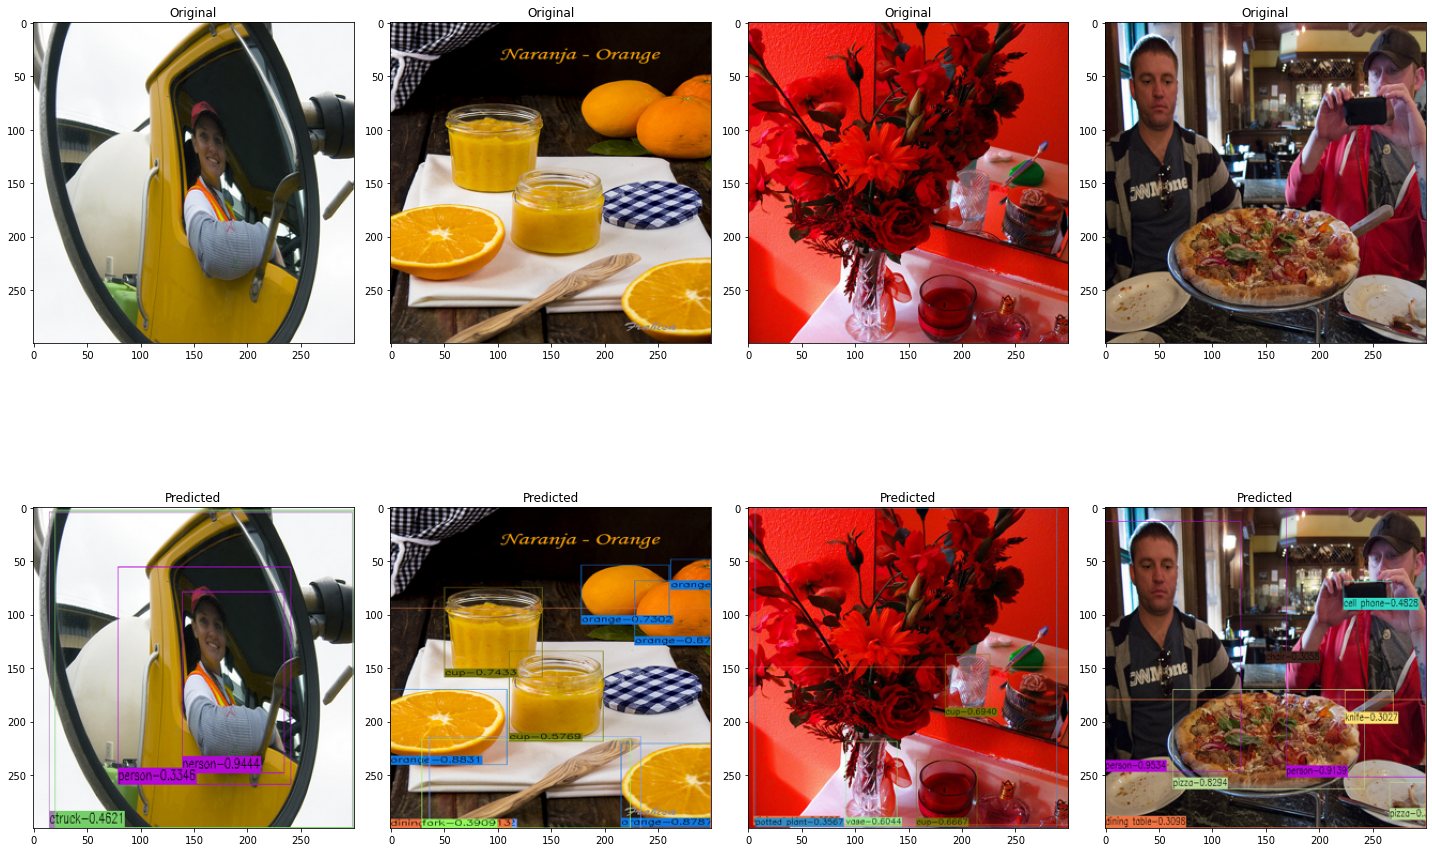

In [ ]:
dir = os.listdir(dir_path) 
path_img=dir[0:4]
k=1
j=5
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True
plt.figure(figsize=(20,20))
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
image_size = image_sizes[phi]
# coco classes
classes = {value['id'] - 1: value['name'] for value in json.load(open('coco_90.json', 'r')).values()}
colors = [np.random.randint(0, 256, 3).tolist() for _ in range(num_classes)]
_, model = efficientdet(phi=phi,
                        weighted_bifpn=weighted_bifpn,
                        num_classes=num_classes,
                        score_threshold=score_threshold)
model.load_weights(ckpt, by_name=True)

for i in path_img:

  image = cv2.imread(dir_path+'/'+ i)
  src_image = image.copy()
  orig_img = cv2.cvtColor(src_image, cv2.COLOR_BGR2RGB)
  # BGR -> RGB
  image = image[:, :, ::-1]
  h, w = image.shape[:2]
  image, scale = preprocess_image(image, image_size=image_size)
  # run network
  start = time.time()
  boxes, scores, labels = model.predict_on_batch([np.expand_dims(image, axis=0)])
  boxes, scores, labels = np.squeeze(boxes), np.squeeze(scores), np.squeeze(labels)
  #print(time.time() - start)
  boxes = postprocess_boxes(boxes=boxes, scale=scale, height=h, width=w)

  # select indices which have a score above the threshold
  indices = np.where(scores[:] > score_threshold)[0]

  # select those detections
  boxes = boxes[indices]
  labels = labels[indices]

  draw_boxes(src_image, boxes, scores, labels, colors, classes)
  output_img = cv2.cvtColor(src_image, cv2.COLOR_BGR2RGB)
  orig_img = Image.fromarray(orig_img)
  img_pred = Image.fromarray(output_img)
  img_pred=img_pred.resize((300,300))
  orig_img=orig_img.resize((300,300))
  plt.subplot(2,4,k)
  plt.imshow(orig_img)
  plt.title('Original')
  plt.subplot(2,4,j)
  plt.imshow(img_pred)
  plt.title('Predicted')
  k=k+1
  j=j+1